In [22]:
import pandas as pd
import numpy as np

In [23]:
df = pd.read_csv('../Data/healthcare_data_encoded.csv')
df = df.set_index('patient_id')

In [31]:
# Filter the dataset to only include adults (18 and older)
df_adult = df[df['age'] >= 18].copy()

print(f"Original unique patients: {len(df)}")
print(f"Adult patients remaining: {len(df_adult)}")

# Separate features (X) from the target (y)
# We also drop 'bmi_was_missing' if it's no longer needed, but let's keep it as it had signal!
X = df_adult.drop(columns=['stroke_event','age_group'])
y = df_adult['stroke_event']

# Check the final class balance before training
print("\nFinal Target Distribution:")
print(y.value_counts(normalize=True) * 100)

Original unique patients: 5110
Adult patients remaining: 4254

Final Target Distribution:
stroke_event
0    94.1937
1     5.8063
Name: proportion, dtype: float64


In [32]:
df_adult.info()

<class 'pandas.DataFrame'>
Index: 4254 entries, 30468 to 43424
Data columns (total 20 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   age                       4254 non-null   float64
 1   has_hypertension          4254 non-null   int64  
 2   has_heart_disease         4254 non-null   int64  
 3   marital_status            4254 non-null   int64  
 4   glucose_level             4254 non-null   float64
 5   bmi_value                 4254 non-null   float64
 6   stroke_event              4254 non-null   int64  
 7   age_group                 4254 non-null   int64  
 8   risk_score                4254 non-null   int64  
 9   high_glucose              4254 non-null   int64  
 10  bmi_category              4254 non-null   int64  
 11  lifestyle_risk            4254 non-null   int64  
 12  bmi_was_missing           4254 non-null   int64  
 13  gender_M                  4254 non-null   int64  
 14  employment_type_oth

In [33]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Split the data (80% training, 20% testing)
# stratify=y ensures the testing set has the exact same ratio of strokes as the training set
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

# Initialize the scaler
scaler = StandardScaler()

# Fit on training data ONLY, then transform both
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Convert back to dataframes for easier handling later (optional but good practice)

X_train_scaled = pd.DataFrame(X_train_scaled, columns=X.columns, index=X_train.index)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X.columns, index=X_test.index)

In [35]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Initialize the model with balanced weights
rf_model = RandomForestClassifier(
    n_estimators=100,          # Build 100 decision trees
    class_weight='balanced',   # Penalize the model heavily for missing a stroke
    random_state=42
)

# Train the model!
print("Training Random Forest...")
rf_model.fit(X_train_scaled, y_train)

# Make predictions on the blind test set
y_pred = rf_model.predict(X_test_scaled)

# Evaluate the results
print("\n--- Classification Report ---")
print(classification_report(y_test, y_pred))

Training Random Forest...

--- Classification Report ---
              precision    recall  f1-score   support

           0       0.94      0.99      0.97       802
           1       0.17      0.02      0.04        49

    accuracy                           0.94       851
   macro avg       0.55      0.51      0.50       851
weighted avg       0.90      0.94      0.91       851



In [36]:
# Run this without SMOTE
from xgboost import XGBClassifier

print("Training XGBoost on original (non-SMOTE) scaled data...")

# Calculate the exact weight for the minority class
# Formula: (Total Negative Cases) / (Total Positive Cases) in the training set
# From your earlier output, we know it's 3205 / 198
weight = 3205 / 198 

# Initialize XGBoost
xgb_model = XGBClassifier(
    scale_pos_weight=weight, 
    random_state=42, 
    eval_metric='logloss'
)

# Train the model (Notice we use X_train_scaled, NOT X_train_smote)
xgb_model.fit(X_train_scaled, y_train)

# Predict on the blind test set
y_pred_xgb = xgb_model.predict(X_test_scaled)

print("\n--- XGBoost Classification Report ---")
print(classification_report(y_test, y_pred_xgb))

Training XGBoost on original (non-SMOTE) scaled data...

--- XGBoost Classification Report ---
              precision    recall  f1-score   support

           0       0.95      0.96      0.95       802
           1       0.15      0.12      0.14        49

    accuracy                           0.91       851
   macro avg       0.55      0.54      0.54       851
weighted avg       0.90      0.91      0.91       851



In [37]:
from imblearn.over_sampling import SMOTE

print("1. Synthesizing new stroke patients using SMOTE...")
# Initialize SMOTE
smote = SMOTE(random_state=42)

# CRITICAL: We only apply SMOTE to the TRAINING data. 
# The test set remains 100% real patients.
X_train_smote, y_train_smote = smote.fit_resample(X_train_scaled, y_train)

print(f"Old training balance: \n{y_train.value_counts()}")
print(f"New training balance: \n{y_train_smote.value_counts()}")

print("\n2. Training new Random Forest...")
# Train the model on the new 50/50 synthesized data
# We no longer need class_weight='balanced' because SMOTE balanced it for us
rf_model_smote = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model_smote.fit(X_train_smote, y_train_smote)

print("\n3. Testing on the blind test set...")
y_pred_smote = rf_model_smote.predict(X_test_scaled)

print("\n--- NEW Classification Report ---")
print(classification_report(y_test, y_pred_smote))

1. Synthesizing new stroke patients using SMOTE...
Old training balance: 
stroke_event
0    3205
1     198
Name: count, dtype: int64
New training balance: 
stroke_event
0    3205
1    3205
Name: count, dtype: int64

2. Training new Random Forest...

3. Testing on the blind test set...

--- NEW Classification Report ---
              precision    recall  f1-score   support

           0       0.95      0.96      0.95       802
           1       0.14      0.10      0.12        49

    accuracy                           0.91       851
   macro avg       0.54      0.53      0.54       851
weighted avg       0.90      0.91      0.91       851



In [38]:
# 1. Get the raw PROBABILITIES instead of the final predictions
# This returns an array where column 0 is % No Stroke, and column 1 is % Stroke
y_probabilities = rf_model_smote.predict_proba(X_test_scaled)

# 2. Extract just the probabilities for Class 1 (Stroke)
stroke_probs = y_probabilities[:, 1]

# 3. Lower the Threshold! 
# Change it so if the model is even 15% sure, it predicts a stroke (1)
custom_threshold = 0.15
y_pred_custom = (stroke_probs >= custom_threshold).astype(int)

# 4. Check the results
print(f"--- Classification Report (Threshold = {custom_threshold}) ---")
print(classification_report(y_test, y_pred_custom))

--- Classification Report (Threshold = 0.15) ---
              precision    recall  f1-score   support

           0       0.97      0.74      0.84       802
           1       0.13      0.63      0.21        49

    accuracy                           0.73       851
   macro avg       0.55      0.69      0.53       851
weighted avg       0.92      0.73      0.80       851



/var/folders/3f/l68d1j3x3598k23pcnmc2c440000gn/T/ipykernel_79328/4196484230.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feature_importance_df, palette='viridis')


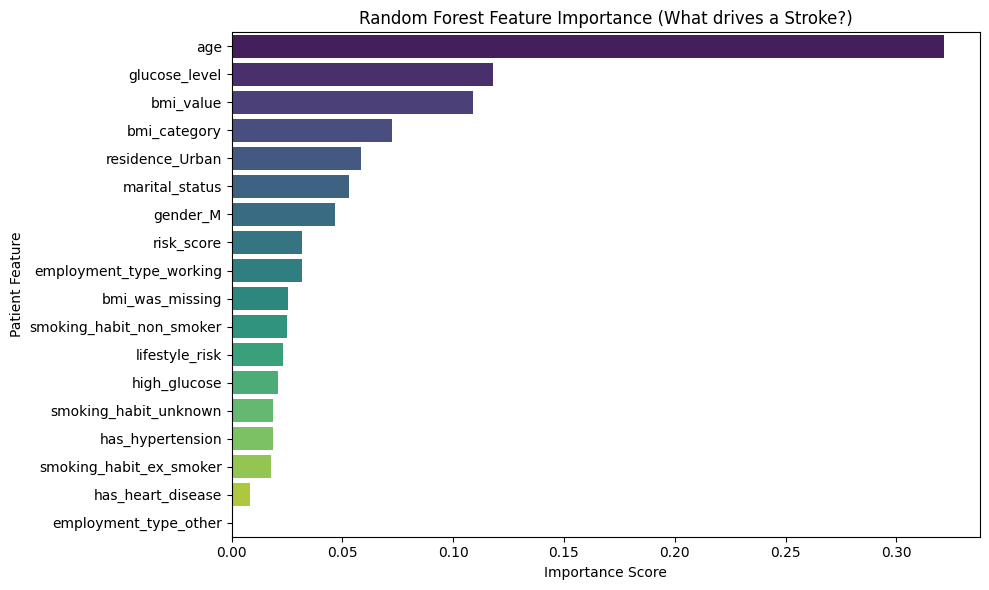

In [39]:
# Extract the feature importances 
# (Make sure you are using rf_model_smote from our previous step)
importances = rf_model_smote.feature_importances_

# Create a dataframe to neatly organize the features and their scores
feature_importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': importances
})

# Sort the features from most important to least important
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

# Plot the results
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df, palette='viridis')
plt.title('Random Forest Feature Importance (What drives a Stroke?)')
plt.xlabel('Importance Score')
plt.ylabel('Patient Feature')
plt.tight_layout()
plt.show()